<h1>Bike Sales Analysis</h1>

<h2>Import Libraries</h2)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

<h2>Load Data</h2>

In [2]:
df = pd.read_csv("/Users/laingangiang/Downloads/Dataset.csv", sep = ";")

<h2>Data Cleaning & Exploration</h2>

<h2>Display the first 10 rows of the DataFrame</h2>

In [3]:
print(df.head(10))

   Product ID Product Category Product Subcategory  \
0        1001   Mountain BIKES       Cross Country   
1        1002   Mountain Bikes       Cross Country   
2        1003       Road Bikes              Racing   
3        1004       Road BIKES              Racing   
4        1005    Touring Bikes       Long Distance   
5        1006    Touring Bikes       Long Distance   
6        1007   Mountain Bikes            Downhill   
7        1008   Mountain Bikes            Downhill   
8        1021   Mountain Bikes               Trail   
9        1022   mountain BIKES               Trail   

                 Product Name                    Product Description  \
0           TrailBlazer 1000               Lightweight and versatile   
1            TrailBlazer 2000         High-performance mountain bike   
2           SpeedMaster 1000         Agile and aerodynamic road bike   
3            SpeedMaster 2000               Premium racing road bike   
4              Explorer 1000    Comfortable a

<h2>Display the last 10 rows of the DataFrame</h2>

In [4]:
print(df.tail(10))

    Product ID Product Category Product Subcategory            Product Name  \
38        1087   Mountain Bikes            Downhill  DownhillDominator 1000   
39        1088   Mountain Bikes            Downhill  DownhillDominator 2000   
40        1101       Kids Bikes             Balance     LittleBalancer 1000   
41        1102       Kids Bikes             Balance     LittleBalancer 2000   
42        1103        BMX Bikes           Freestyle    FreestyleMaster 1000   
43        1104        BMX Bikes           Freestyle    FreestyleMaster 2000   
44        1105   Mountain Bikes       Cross Country           XC-Rider 1000   
45        1106   Mountain Bikes       Cross Country           XC-Rider 2000   
46        1107       ROAD BIKES           Endurance     EnduranceElite 1000   
47        1108       Road Bikes           Endurance     EnduranceElite 2000   

                        Product Description  Product Price  Product Weight  \
38                   Downhill mountain bike         

<h2>Remove rows and columns with missing values</h2>

In [5]:
df = df.dropna(axis=0)
df = df.dropna(axis=1)
print("Remove rows and columns with missing values successfully.")

Remove rows and columns with missing values successfully.


<h2>Display the data set summary about the DataFrame</h2>

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 46 entries, 0 to 47
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product ID           46 non-null     int64  
 1   Product Category     46 non-null     object 
 2   Product Subcategory  46 non-null     object 
 3   Product Name         46 non-null     object 
 4   Product Description  46 non-null     object 
 5   Product Price        46 non-null     float64
 6   Product Weight       46 non-null     float64
 7   Product Size         46 non-null     object 
 8   Order ID             46 non-null     int64  
 9   Customer ID          46 non-null     int64  
 10  Order Date           46 non-null     object 
 11  Order Status         46 non-null     object 
 12  Order Quantity       46 non-null     int64  
 13  Order Total          46 non-null     float64
 14  Payment Method       46 non-null     object 
dtypes: float64(3), int64(4), object(8)
memory usage

<h2>Display the statistical summary of the DataFrame</h2>

In [7]:
print(df.describe())

        Product ID  Product Price  Product Weight     Order ID  Customer ID  \
count    46.000000      46.000000       46.000000    46.000000    46.000000   
mean   1056.152174    1966.304348       26.152174  2056.152174  3056.152174   
std      34.349166     812.681046        7.624427    34.349166    34.349166   
min    1001.000000     150.000000        9.000000  2001.000000  3001.000000   
25%    1026.250000    1500.000000       20.250000  2026.250000  3026.250000   
50%    1061.500000    2000.000000       26.500000  2061.500000  3061.500000   
75%    1084.750000    2400.000000       31.500000  2084.750000  3084.750000   
max    1108.000000    3700.000000       42.000000  2108.000000  3108.000000   

       Order Quantity  Order Total  
count       46.000000    46.000000  
mean         1.630435  3093.478261  
std          0.710515  1725.160498  
min          1.000000   200.000000  
25%          1.000000  2025.000000  
50%          1.500000  2600.000000  
75%          2.000000  4000.0

In [8]:
# Display the original data types of each column in the DataFrame
print(df.dtypes)

Product ID               int64
Product Category        object
Product Subcategory     object
Product Name            object
Product Description     object
Product Price          float64
Product Weight         float64
Product Size            object
Order ID                 int64
Customer ID              int64
Order Date              object
Order Status            object
Order Quantity           int64
Order Total            float64
Payment Method          object
dtype: object


<h2>Average Product Price by Category</h2>

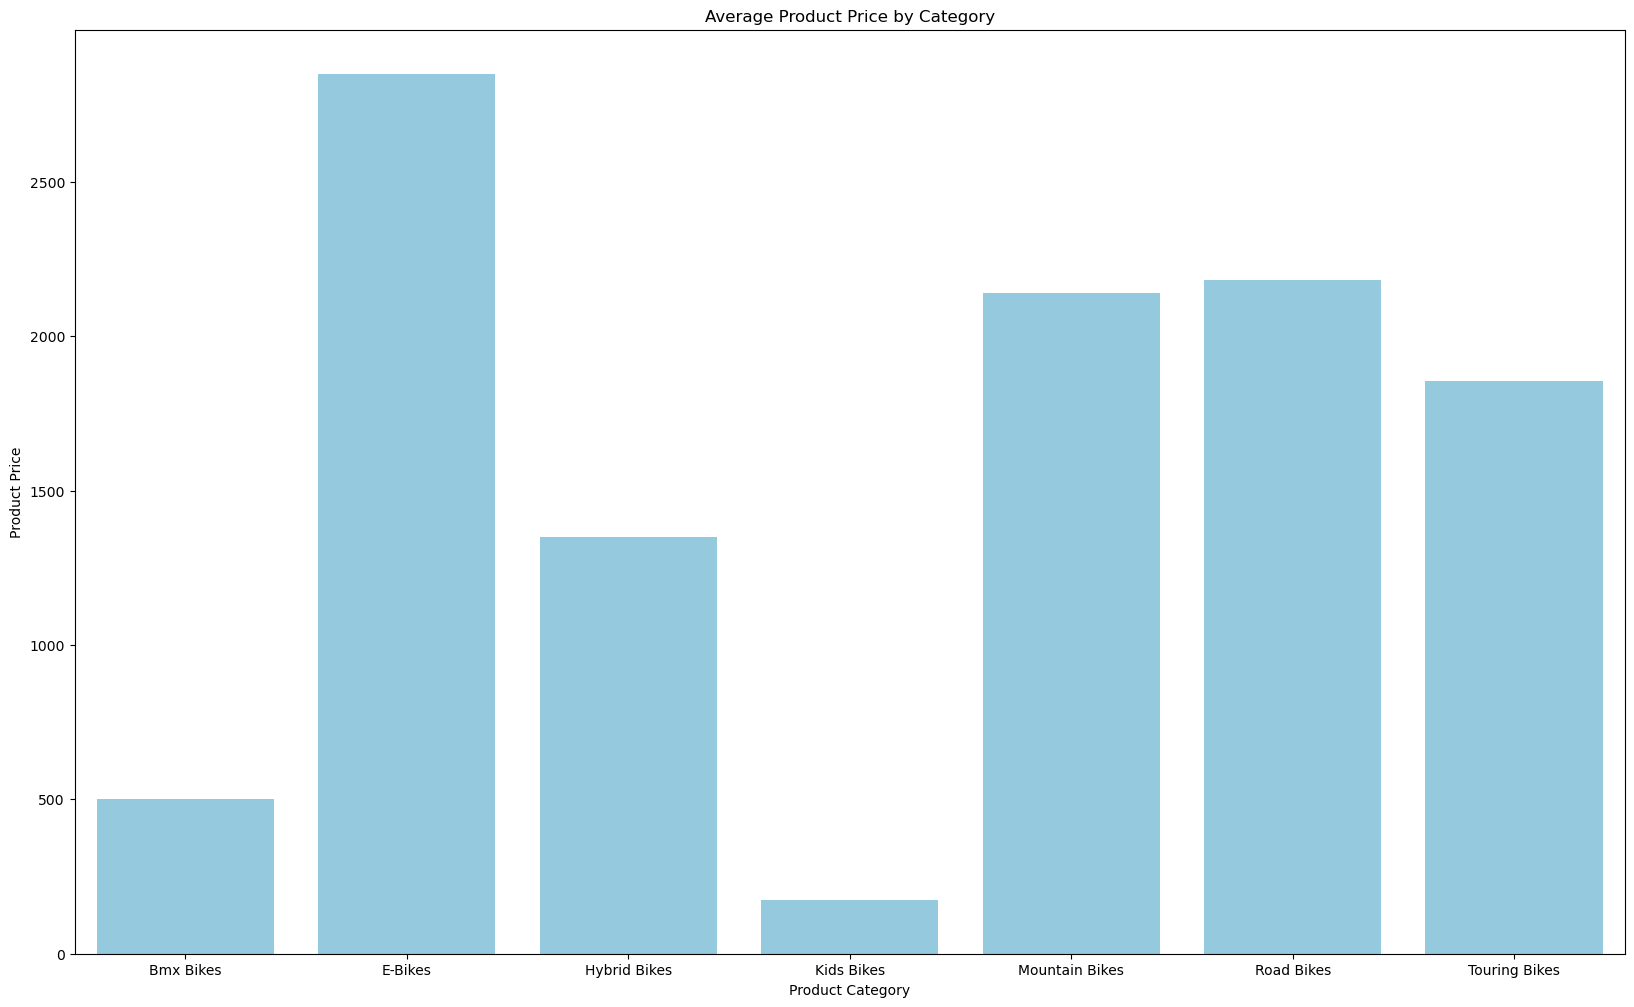

In [9]:
df["Product Category"] = df["Product Category"].str.title()

Avg_Product_Price = df.groupby("Product Category")["Product Price"].mean().reset_index()

plt.figure(figsize = (20, 12))
sns.barplot(data = Avg_Product_Price, x = "Product Category", y = "Product Price", color="skyblue")
plt.title("Average Product Price by Category")
plt.show()

<h2>Number of Subcategories per Product Category</h2>

In [10]:
Subcategory_Count = df.groupby("Product Category")["Product Subcategory"].count().reset_index()
Subcategory_Count.columns = ["Product Category", "Count"]

print(Subcategory_Count)

  Product Category  Count
0        Bmx Bikes      2
1          E-Bikes      4
2     Hybrid Bikes      2
3       Kids Bikes      2
4   Mountain Bikes     15
5       Road Bikes     12
6    Touring Bikes      9


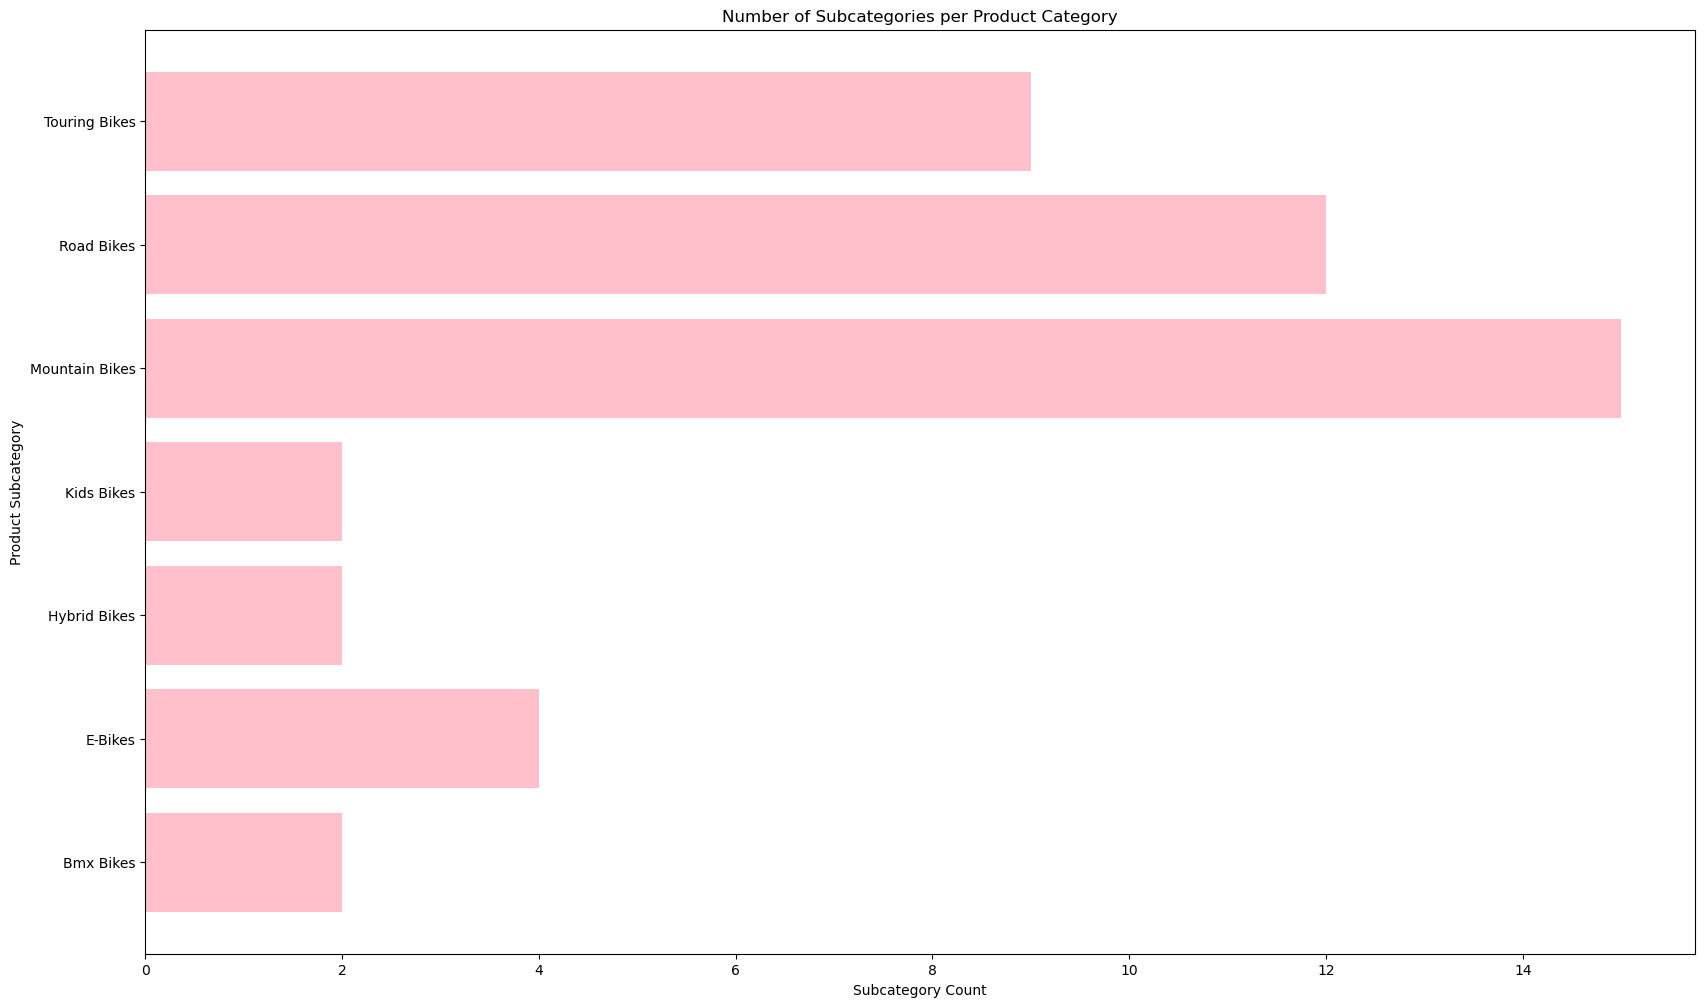

In [11]:
category = Subcategory_Count["Product Category"]
value = Subcategory_Count["Count"]

plt.figure(figsize = (20, 12))
plt.barh(category, value, color = "pink")
plt.xlabel("Subcategory Count")
plt.ylabel("Product Subcategory")
plt.title("Number of Subcategories per Product Category")
plt.show()

<h2>Order Quantity by Category & Order Total by Category</h2>

In [12]:
Cat_Summary = df.groupby("Product Category").agg(
    Order_Quantity=("Order Quantity", "sum"),
    Order_Total=("Order Total", "sum")
).reset_index()

print(Cat_Summary)

  Product Category  Order_Quantity  Order_Total
0        Bmx Bikes               4       1800.0
1          E-Bikes               6      16600.0
2     Hybrid Bikes               3       3900.0
3       Kids Bikes               3        500.0
4   Mountain Bikes              23      47900.0
5       Road Bikes              23      48100.0
6    Touring Bikes              13      23500.0


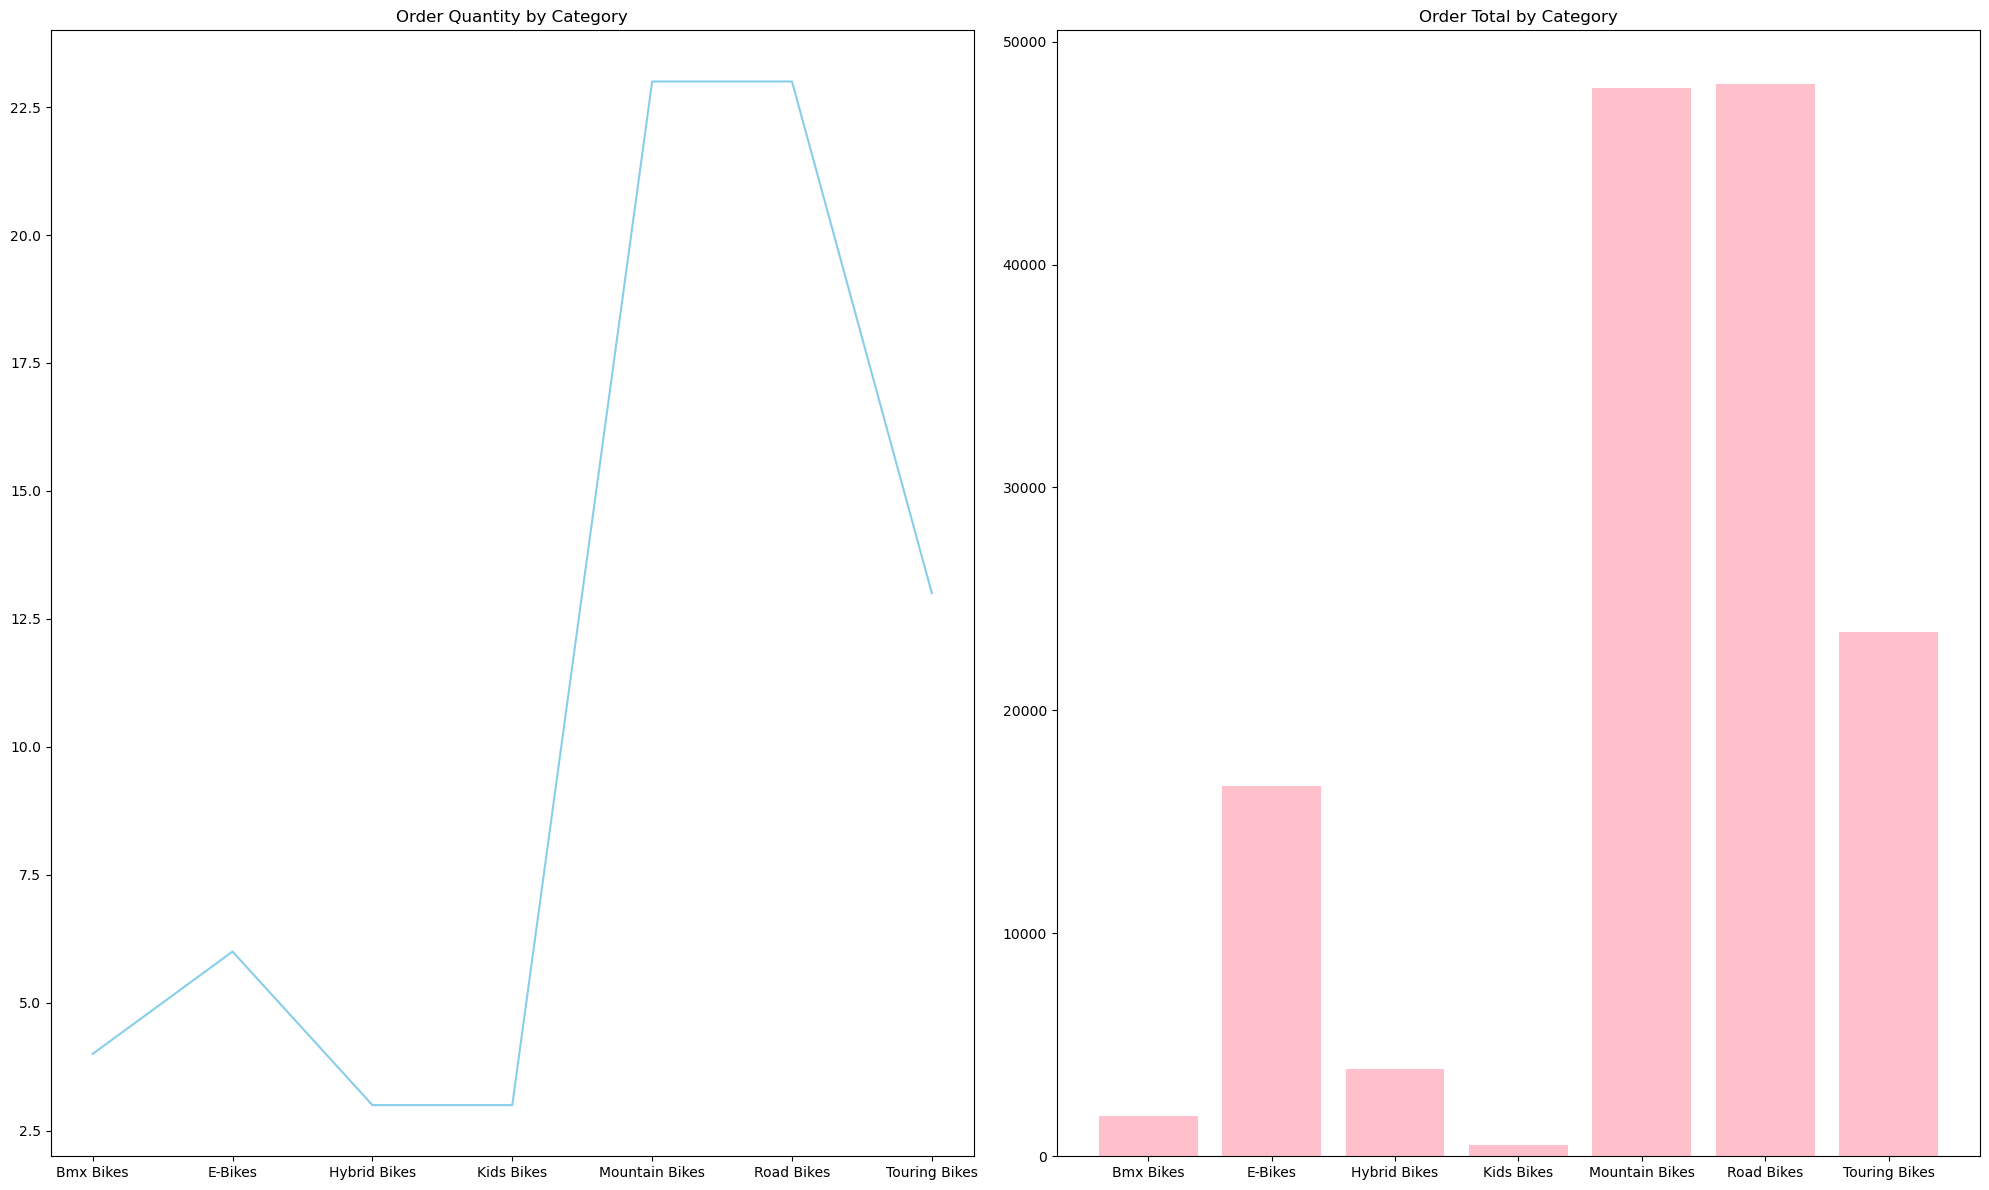

In [13]:
fig, ax = plt.subplots(1, 2, figsize = (20, 12))

# Order Quantity by Category
ax[0].plot(Cat_Summary["Product Category"], Cat_Summary["Order_Quantity"], color="skyblue")
ax[0].set_title("Order Quantity by Category")

# Order Total by Category
ax[1].bar(Cat_Summary["Product Category"], Cat_Summary["Order_Total"], color="pink")
ax[1].set_title("Order Total by Category")

plt.tight_layout()
plt.show()

<h2>Orders by Status</h2>

In [14]:
Order_status_count = df["Order Status"].value_counts().reset_index()
Order_status_count.columns = ["Order Status", "Count"]

print(Order_status_count)

  Order Status  Count
0      Shipped     24
1   Processing     16
2    Cancelled      6


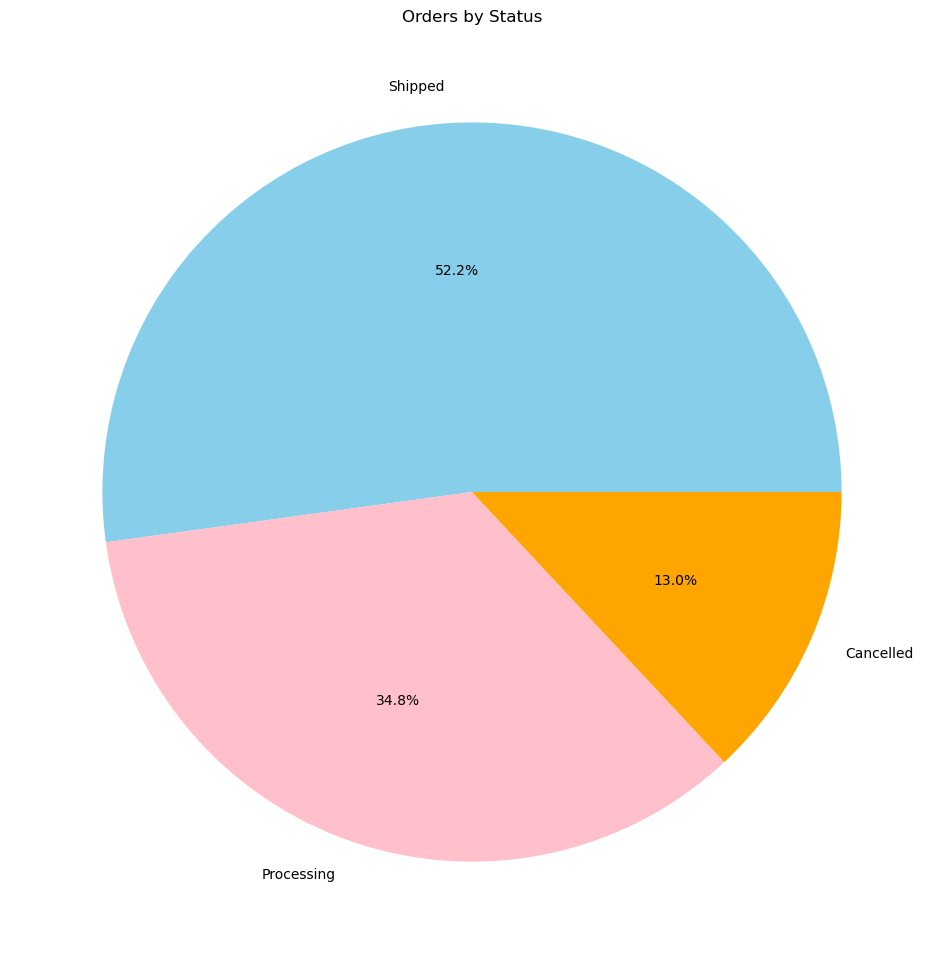

In [15]:
plt.figure(figsize = (20, 12))
plt.pie(Order_status_count["Count"], labels = Order_status_count["Order Status"], autopct="%1.1f%%", colors=["skyblue", "pink", "orange"])
plt.title("Orders by Status")
plt.show()

<h2>Top 10 Best-Selling Products</2>

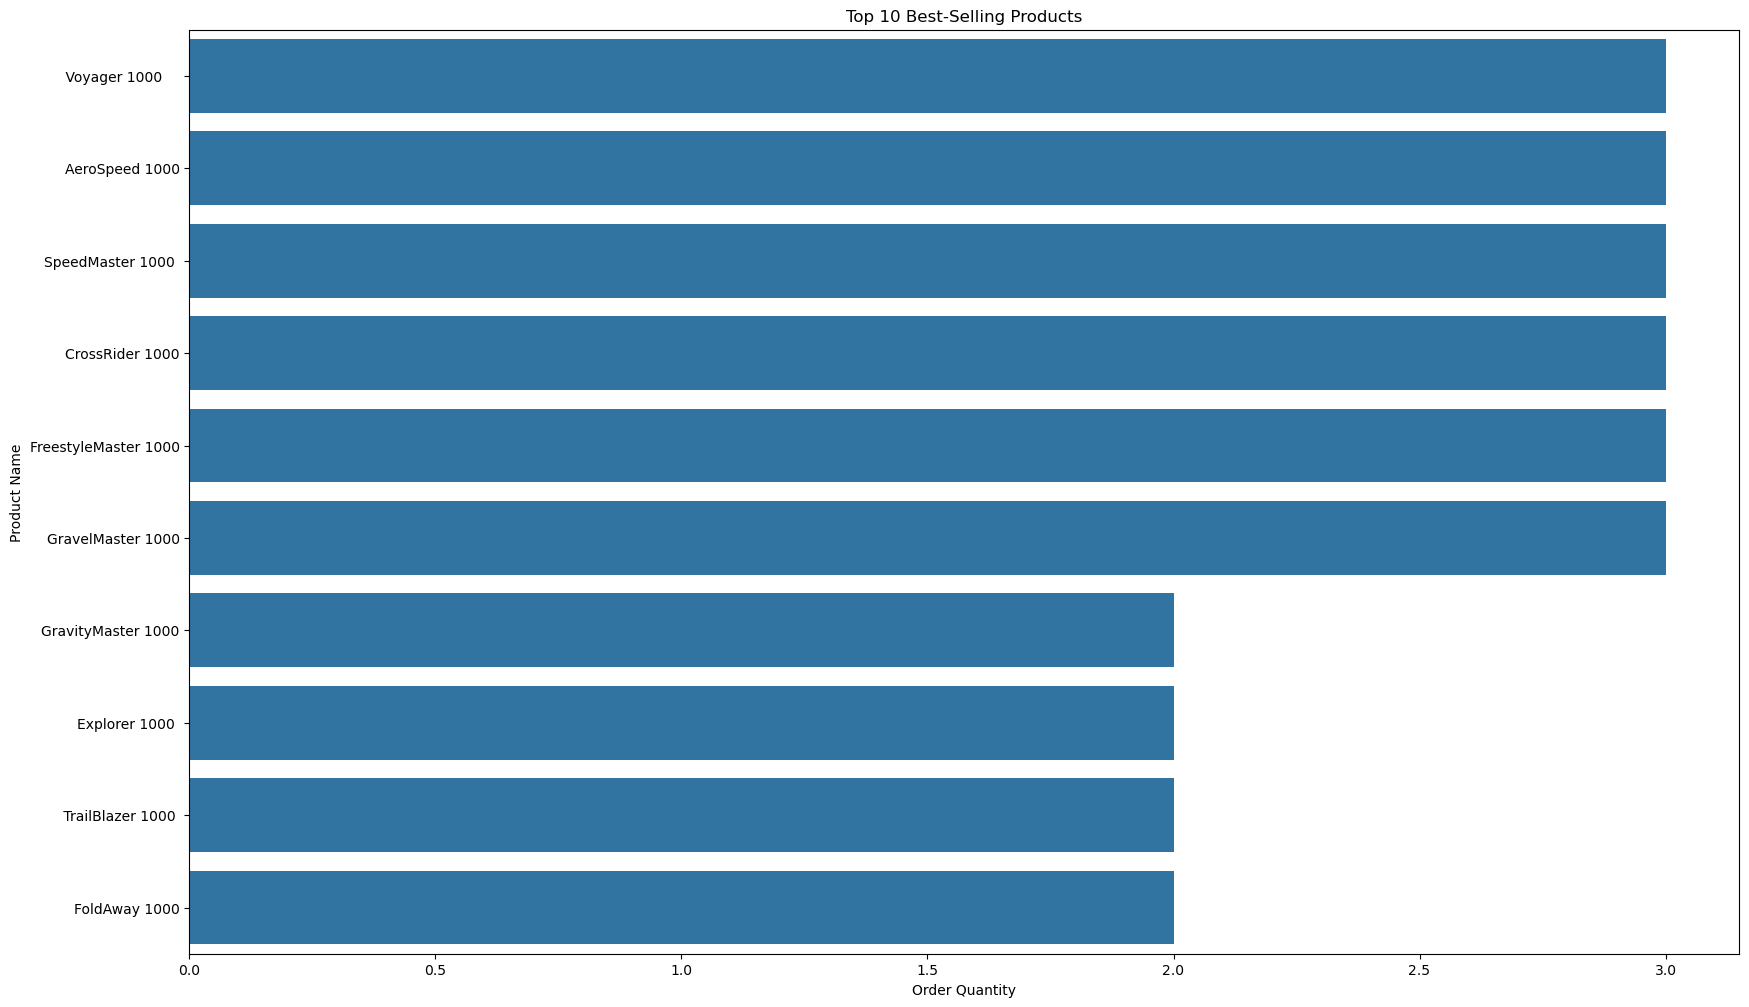

In [16]:
Top_Products = df.groupby("Product Name")["Order Quantity"].sum().reset_index()
Top_Products = Top_Products.sort_values("Order Quantity", ascending=False).head(10)

plt.figure(figsize = (20, 12))
sns.barplot(data=Top_Products, x="Order Quantity", y="Product Name")
plt.title("Top 10 Best-Selling Products")
plt.show()

<h2>The most popular payment method</h2>

Text(0.5, 1.0, 'The most popular payment method')

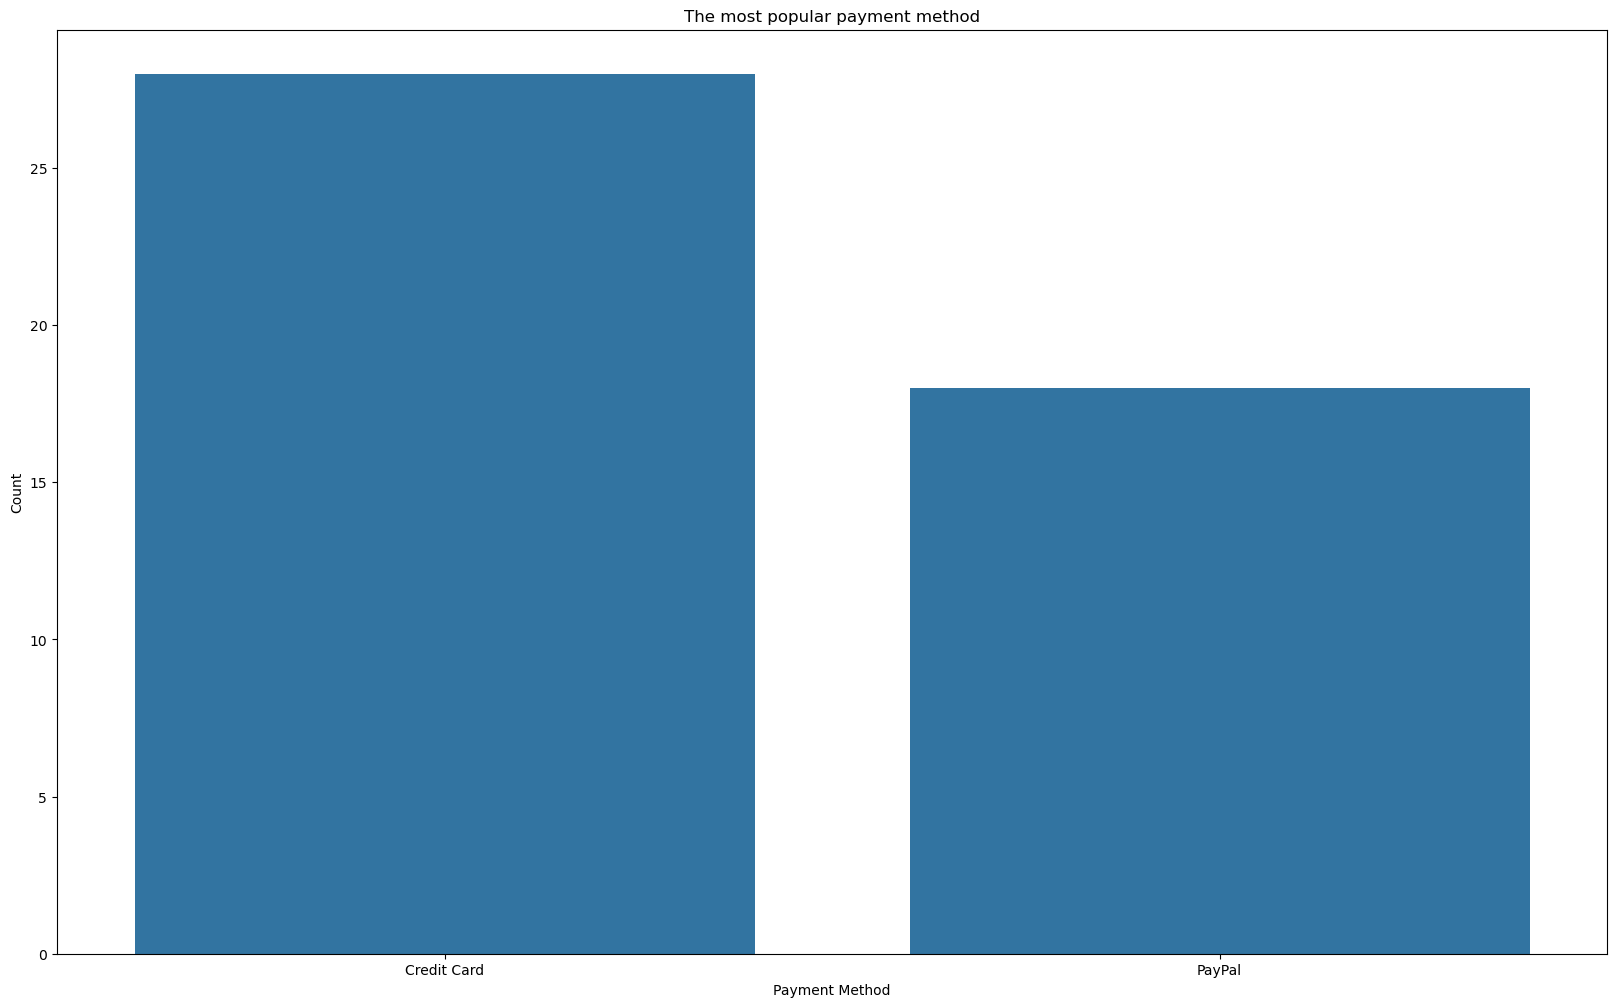

In [17]:
Payment_Count = df["Payment Method"].value_counts().reset_index()
Payment_Count.columns = ["Payment Method", "Count"]

plt.figure(figsize = (20, 12))
sns.barplot(data=Payment_Count, x="Payment Method", y="Count")
plt.title("The most popular payment method")

<h2>The relationship between price and order quantity</h2>

Text(0.5, 1.0, 'The relationship between price and order quantity')

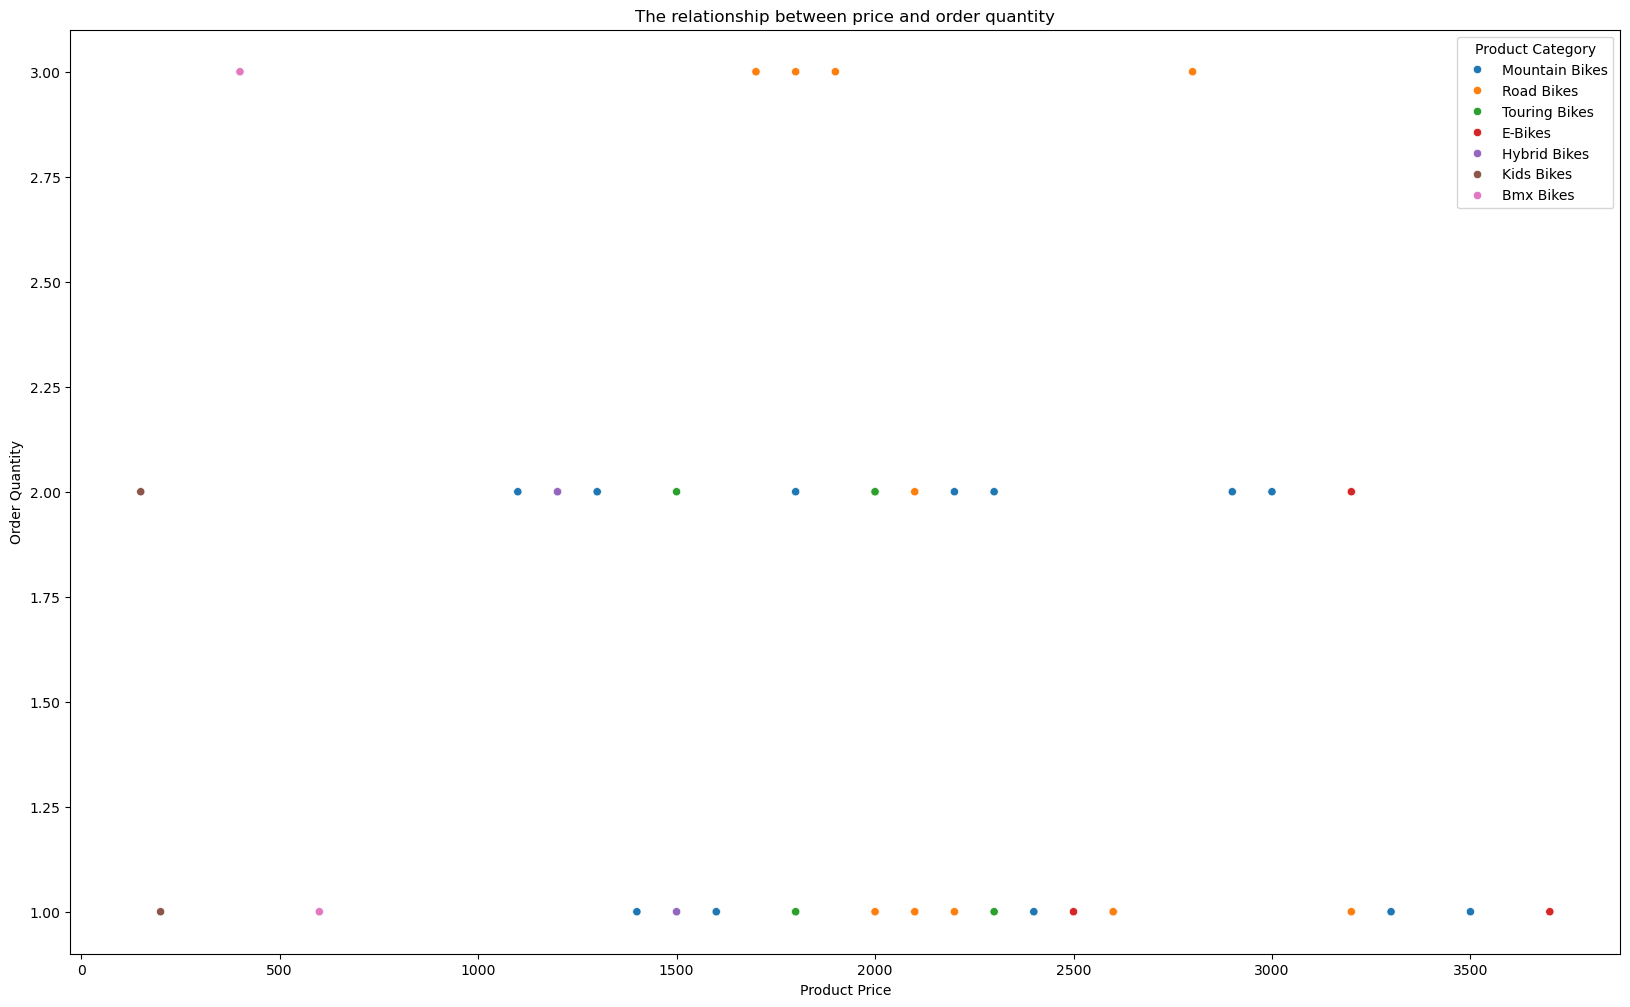

In [18]:
plt.figure(figsize = (20, 12))
sns.scatterplot(data=df, x="Product Price", y="Order Quantity", hue="Product Category")
plt.title("The relationship between price and order quantity")